<a href="https://colab.research.google.com/github/faiq191/244107020214-machine-learning/blob/main/JS03/JS03_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

df = pd.read_csv('wbc.csv')
print(f"Dimensi awal dataset: {df.shape}")
df.head()

Dimensi awal dataset: (569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [4]:
# 1. Differentiate usable vs non-usable variables
cols_to_drop = ['id', 'Unnamed: 32'] if 'Unnamed: 32' in df.columns else ['id']
df_clean = df.drop(columns=cols_to_drop)

X = df_clean.drop(columns=['diagnosis'])
y = df_clean['diagnosis']

# 2. Encoding target diagnosis (M = 1, B = 0)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(f"Fitur numerik usable : {X.shape[1]} kolom")
print(f"Target encoding     : {dict(zip(le.classes_, le.transform(le.classes_)))}")

Fitur numerik usable : 30 kolom
Target encoding     : {'B': np.int64(0), 'M': np.int64(1)}


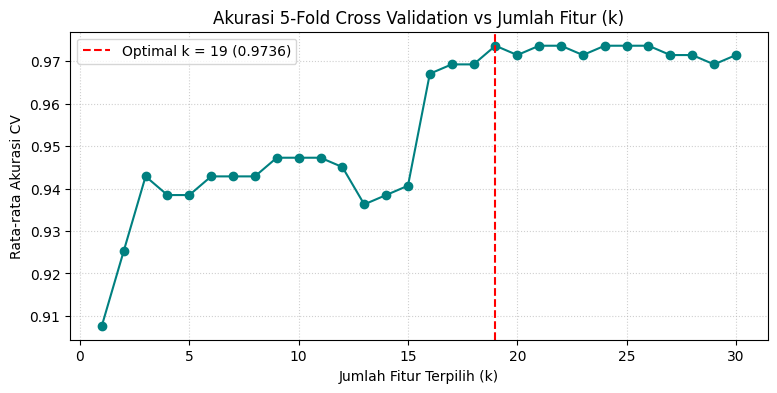

Jumlah fitur optimal (k): 19 dengan Akurasi CV: 97.36%


In [5]:
# Steps 3, 4, 5, & 6 (Pipeline, Standardization & Optimal Feature Search)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

k_range = range(1, X.shape[1] + 1)
cv_scores = []

for k in k_range:
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('select_k', SelectKBest(score_func=f_classif, k=k)),
        ('classifier', LogisticRegression(max_iter=1000, random_state=42))
    ])
    score = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='accuracy').mean()
    cv_scores.append(score)

optimal_k = list(k_range)[np.argmax(cv_scores)]
best_cv_score = max(cv_scores)

plt.figure(figsize=(9, 4))
plt.plot(k_range, cv_scores, marker='o', color='teal', linewidth=1.5)
plt.axvline(optimal_k, color='red', linestyle='--', label=f'Optimal k = {optimal_k} ({best_cv_score:.4f})')
plt.title('Akurasi 5-Fold Cross Validation vs Jumlah Fitur (k)')
plt.xlabel('Jumlah Fitur Terpilih (k)')
plt.ylabel('Rata-rata Akurasi CV')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

print(f"Jumlah fitur optimal (k): {optimal_k} dengan Akurasi CV: {best_cv_score * 100:.2f}%")

In [14]:
# Step 7 (Final Model Evaluation & Selected Features Display)
final_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('select_k', SelectKBest(score_func=f_classif, k=optimal_k)),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

final_pipeline.fit(X_train, y_train)
y_pred = final_pipeline.predict(X_test)

print("=== Hasil Evaluasi Test Set ===")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))

#
selector = final_pipeline.named_steps['select_k']
selected_mask = selector.get_support()
selected_features = X.columns[selected_mask]
feature_scores = selector.scores_[selected_mask]

ranking_df = pd.DataFrame({
    'Fitur': selected_features,
    'F-Score (ANOVA)': feature_scores
}).sort_values(by='F-Score (ANOVA)', ascending=False).reset_index(drop=True)

print(f"\n=== Daftar {optimal_k} Fitur Optimal Terpilih ===")
print(ranking_df.to_string(index=False))

=== Hasil Evaluasi Test Set ===
Test Accuracy: 98.25%

              precision    recall  f1-score   support

           B       0.97      1.00      0.99        72
           M       1.00      0.95      0.98        42

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114


=== Daftar 19 Fitur Optimal Terpilih ===
               Fitur  F-Score (ANOVA)
concave points_worst       733.724933
     perimeter_worst       717.246487
        radius_worst       692.861395
 concave points_mean       684.526845
      perimeter_mean       548.413236
          area_worst       522.188947
         radius_mean       511.274848
           area_mean       444.857518
      concavity_mean       397.592082
     concavity_worst       319.507776
    compactness_mean       263.564326
   compactness_worst       238.203725
           radius_se       205.433206
        perimeter_se       193.168931
      